In [3]:
from pathlib import Path
from typing import Tuple

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage, signal

from tqdm import tqdm
import math

# np.set_printoptions(precision=4)

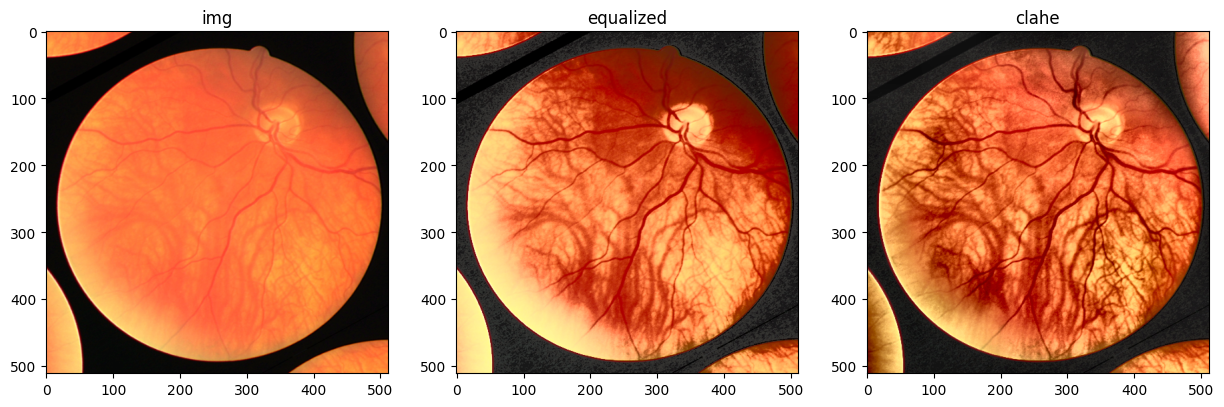

In [9]:
input_dir = Path('./retina.png')
shift_0 = cv.imread(str(input_dir))
img = cv.cvtColor(shift_0, cv.COLOR_BGR2LAB)
img_equalized = cv.equalizeHist(img[:,:,0])
img_clahe = cv.createCLAHE(clipLimit=10.0, tileGridSize=(8,8)).apply(img[:,:,0])

def merge_to_rgb(new_l_channel, old_image_lab):
    new_lab_img = cv.merge([new_l_channel, old_image_lab[:,:,1], old_image_lab[:,:,2]])
    rgb_image = cv.cvtColor(new_lab_img, cv.COLOR_Lab2RGB)
    return rgb_image

plt.figure(figsize=(15,15))
plt.subplot(131)
plt.title("img")
plt.imshow(merge_to_rgb(img[:,:,0], img))
plt.subplot(132)
plt.title("equalized")
plt.imshow(merge_to_rgb(img_equalized, img))
plt.subplot(133)
plt.title("clahe")
plt.imshow(merge_to_rgb(img_clahe, img))
plt.show()


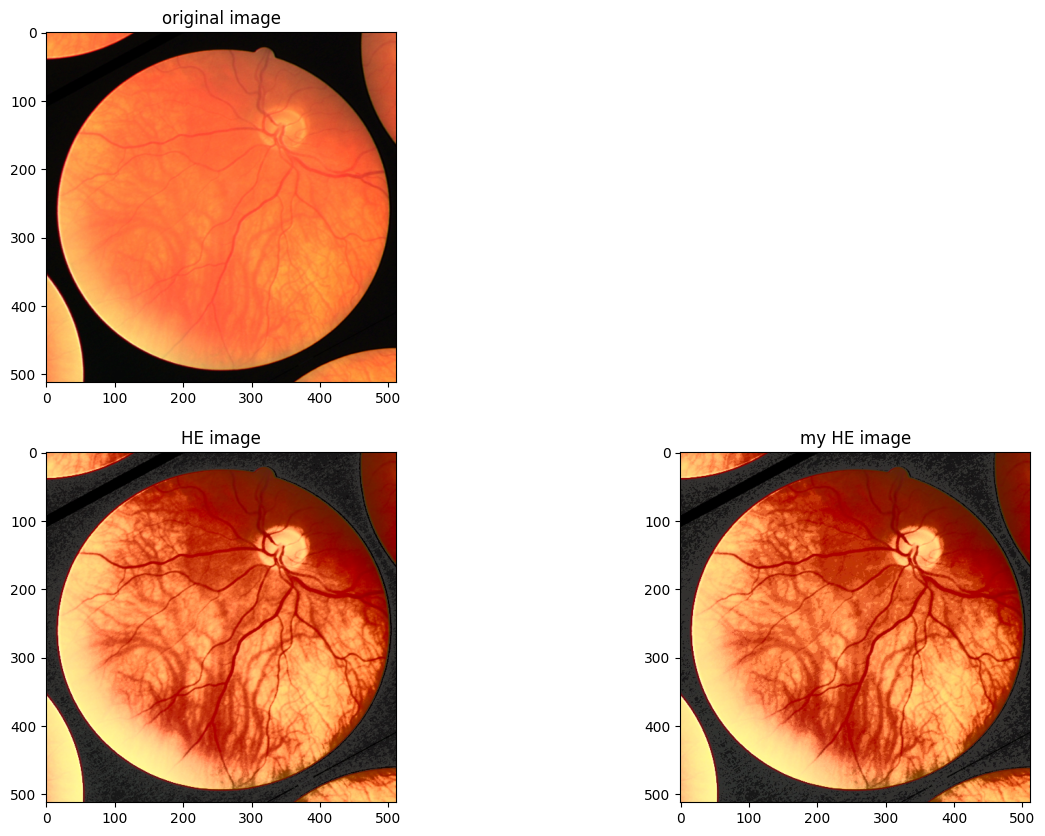

In [23]:
def show_histogram(img, num_bins=20):
    l = img
    counts, bins = np.histogram(l, bins=num_bins, range=(0,255))
    plt.stairs(counts, bins)
    cdf = np.cumsum(counts)
    # plt.plot(bins[:-1], cdf, color='blue') 
    plt.show()

def my_equalize(img, num_bins=100):
    counts, bins = np.histogram(img, bins=num_bins, range=(0,255))
    cfd = np.cumsum(counts)
    bin_edges = np.linspace(0, 255, num_bins)
    # np.digitize returns the indices of the bins to which each value in the input array belongs
    binned_image = np.digitize(img, bins=bin_edges) - 1  # Subtract 1 to get zero-indexed bins
    new_img = np.zeros_like(binned_image, np.uint8)
    cfd_min = min(cfd)
    cfd_max = img.shape[0] * img.shape[1]
    for i in range(binned_image.shape[0]):
        for j in range(binned_image.shape[1]):
            bin_index = binned_image[i,j]
            new_img[i,j] = ((cfd[bin_index] - cfd_min)* 255 / (cfd_max - cfd_min) )

    return new_img


he_img = cv.equalizeHist(img[:,:,0])
my_he_img = my_equalize(img[:,:,0])
plt.figure(figsize=(15,10))
plt.subplot(221)
plt.title("original image")
plt.imshow(merge_to_rgb(img[:,:,0], img))
plt.subplot(223)
plt.title("HE image")
plt.imshow(merge_to_rgb(he_img, img))
plt.subplot(224)
plt.title("my HE image")
plt.imshow(merge_to_rgb(my_he_img, img))
plt.show()

# show_histogram(img[:,:,0])
# show_histogram(he_img)
# show_histogram(my_he_img)

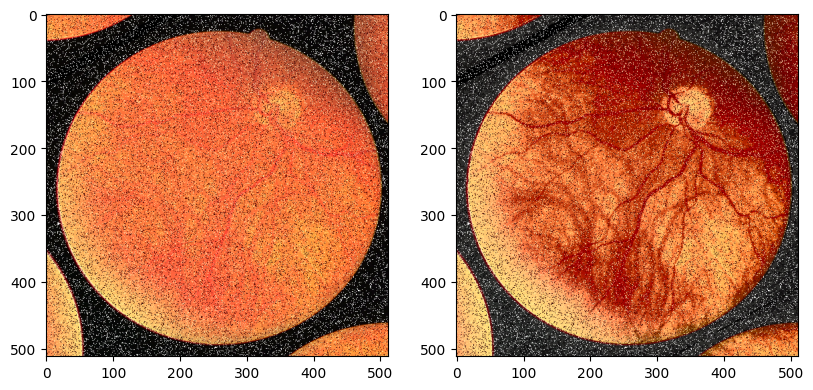

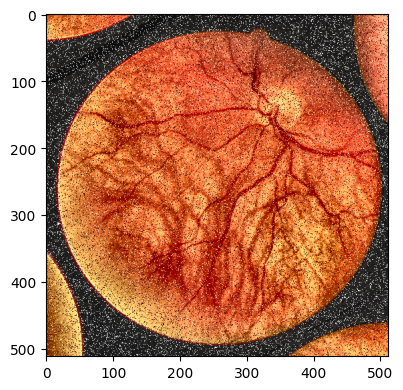

In [31]:
def add_salt_and_pepper_noise(image, salt_prob, pepper_prob):
    # Convert image to float32 if it's not already
    noisy_image = image.copy().astype(float)
    
    # Generate random noise
    salt_noise = np.random.rand(*image.shape) < salt_prob
    pepper_noise = np.random.rand(*image.shape) < pepper_prob
    
    # Add salt noise (white pixels)
    noisy_image[salt_noise] = 255
    
    # Add pepper noise (black pixels)
    noisy_image[pepper_noise] = 0
    
    # Clip the image to be in the valid range [0, 255] and convert back to uint8
    noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8)
    
    return noisy_image

noisy_l = add_salt_and_pepper_noise(img[:,:,0], 0.1,0.1)
# noisy_l = cv.GaussianBlur(img[:,:,0],(11,11),1)
noisy_l_equalized = my_equalize(noisy_l)
noisy_l_clahe = cv.createCLAHE(clipLimit=10.0, tileGridSize=(8,8)).apply(noisy_l)

plt.figure(figsize=(15,10))
plt.subplot(131)
plt.imshow(merge_to_rgb(noisy_l, img))
plt.subplot(132)
plt.imshow(merge_to_rgb(noisy_l_equalized, img))
plt.figure(figsize=(15,10))
plt.subplot(133)
plt.imshow(merge_to_rgb(noisy_l_clahe, img))

In [145]:
def apply_CLAHE(img, tile_size=8, clip_limit=10):
    # need to do img[tile_start:tile_end, tile_start:tile_end] = equalize(img[tile_start:tile_end, tile_start:tile_end])
    # Need to do bilinear interpolation for inside squares
    # Need to do special types of interpolation for edge and corner squares ( might just maybe skip this part)
    pass 
    

[[[1 2 3 4 5]
  [1 2 3 4 5]
  [1 2 3 4 5]]

 [[1 2 3 4 5]
  [1 2 3 4 5]
  [1 2 3 4 5]]

 [[1 2 3 4 5]
  [1 2 3 4 5]
  [1 2 3 4 5]]

 [[1 2 3 4 5]
  [1 2 3 4 5]
  [1 2 3 4 6]]]
[[[0 1 1 2 2]
  [0 1 1 2 2]
  [0 1 1 2 2]]

 [[0 1 1 2 2]
  [0 1 1 2 2]
  [0 1 1 2 2]]

 [[0 1 1 2 2]
  [0 1 1 2 2]
  [0 1 1 2 2]]

 [[0 1 1 2 2]
  [0 1 1 2 2]
  [0 1 1 2 3]]]
